In [8]:
import pandas as pd

DATA_PATH = "./data/train.csv"
df = pd.read_csv(DATA_PATH) # DataFrame = tabellarischer Datensatz
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.shape # Matrixdimension (Anzahl Zeilen, Anzahl Spalten) 

(891, 12)

In [10]:
list(df.columns) # Spaltenliste

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [14]:
df.describe().T # Beschreibende Statistik

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [ ]:
df.isna().sum().sort_values(ascending=False) # Summe von fehlenden Werten je spalte 

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [19]:
(df.isna().mean()*100).round(2).sort_values(ascending=False) # Summe von fehlenden Werten je spalte 

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64

Cabin          77.10 - Spalte löschen

Age            19.87 - Werte auffüllen

Embarked        0.22 - Zeilen löschen

In [20]:
df[
    [
        "Name",
        "Age",
    ]
] # Spaltenuntermenge

,Name,Age
0,"Braund, Mr. Owen Harris",22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0
4,"Allen, Mr. William Henry",35.0
...,...,...
886,"Montvila, Rev. Juozas",27.0
887,"Graham, Miss. Margaret Edith",19.0
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN
889,"Behr, Mr. Karl Howell",26.0


In [ ]:
minors = df[ df["Age"] < 18 ]
minors

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S
852,853,0,3,"Boulos, Miss. Nourelain",female,9.0,1,1,2678,15.2458,NaN,C
853,854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


In [24]:
(df["Age"] < 18).head(10) # Boolesche Maske 

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8    False
9     True
Name: Age, dtype: bool

In [25]:
mask = (df["Sex"] == "female") & (df["Pclass"] == 1) # Frauen in 1st class
df[mask]["Name"]

1      Cumings, Mrs. John Bradley (Florence Briggs Th...
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
11                              Bonnell, Miss. Elizabeth
31        Spencer, Mrs. William Augustus (Marie Eugenie)
52              Harper, Mrs. Henry Sleeper (Myna Haxtun)
                             ...                        
856           Wick, Mrs. George Dennick (Mary Hitchcock)
862    Swift, Mrs. Frederick Joel (Margaret Welles Ba...
871     Beckwith, Mrs. Richard Leonard (Sallie Monypeny)
879        Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)
887                         Graham, Miss. Margaret Edith
Name: Name, Length: 94, dtype: str

In [ ]:
# Wählen Sie alle Männer aus, die mehr als $ 20 für ihr Ticket bezahlt haben 


In [29]:
# Spalten = Features  auswählen 

feat_df = df[[
    #'PassengerId',
    'Survived',
    'Pclass',
    #'Name',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    #'Ticket',
    'Fare',
    #'Cabin',
    'Embarked',
]
]

In [30]:
feat_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [47]:
# unkritische Lösung von Embarked 

mask = ~(feat_df["Embarked"].isna()) # ~ ist Negation/Verneinung
feat_df = feat_df[mask]

In [ ]:
feat_df

In [53]:
# Flagging 
mask = feat_df["Age"].isna()
feat_df["Age_missing"] = mask.astype(int)
feat_df["Age"] = feat_df["Age"].fillna(feat_df["Age"].median()) # mit Median auffüllen 
feat_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_missing
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,0
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,0
4,0,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,0
887,1,1,female,19.0,0,0,30.0000,S,0
888,0,3,female,28.0,1,2,23.4500,S,1
889,1,1,male,26.0,0,0,30.0000,C,0


In [ ]:
%pip install seaborn

In [55]:
import seaborn as sns 
import matplotlib.pyplot as plt 

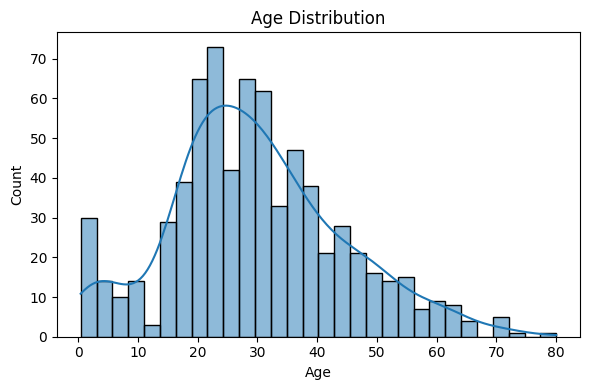

In [56]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=30, color="#1f77b4", kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

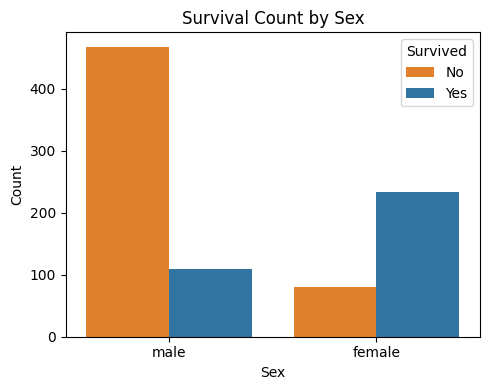

In [57]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Sex", hue="Survived", palette=["#ff7f0e", "#1f77b4"])
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

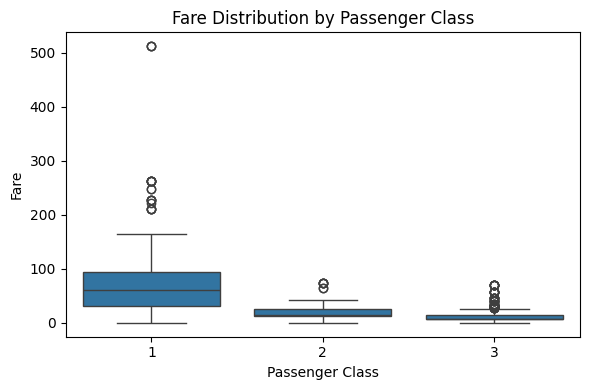

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

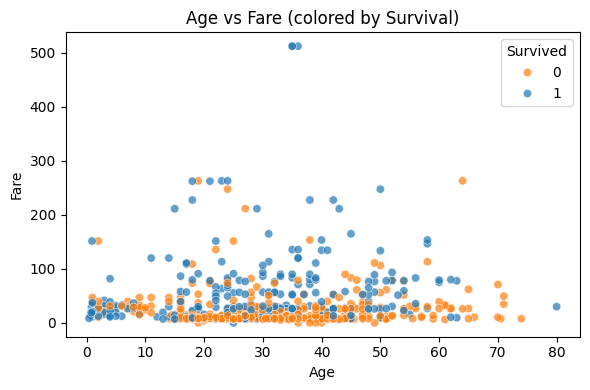

In [59]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived",
                palette=["#ff7f0e", "#1f77b4"], alpha=0.7)
plt.title("Age vs Fare (colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

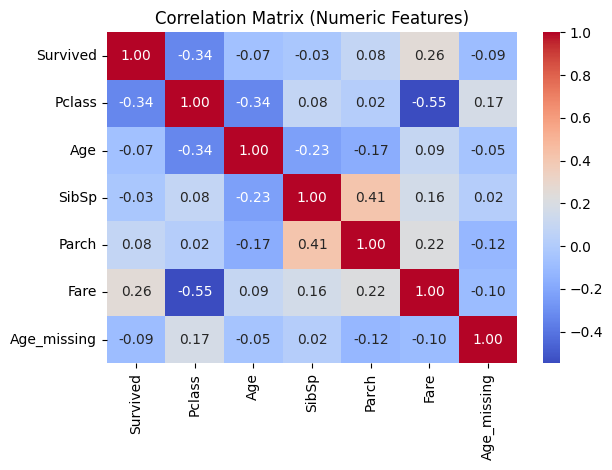

In [60]:
sns.heatmap(feat_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()

In [ ]:
X = feat_df.drop("Survived", axis=1)
y = df["Survived"]

(X,y) # 

(     Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Age_missing
 0         3    male  22.0      1      0   7.2500        S            0
 1         1  female  38.0      1      0  71.2833        C            0
 2         3  female  26.0      0      0   7.9250        S            0
 3         1  female  35.0      1      0  53.1000        S            0
 4         3    male  35.0      0      0   8.0500        S            0
 ..      ...     ...   ...    ...    ...      ...      ...          ...
 886       2    male  27.0      0      0  13.0000        S            0
 887       1  female  19.0      0      0  30.0000        S            0
 888       3  female  28.0      1      2  23.4500        S            1
 889       1    male  26.0      0      0  30.0000        C            0
 890       3    male  32.0      0      0   7.7500        Q            0
 
 [889 rows x 8 columns],
 0      0
 1      1
 2      1
 3      1
 4      0
       ..
 886    0
 887    1
 888    0
 889    1
 890    0

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

le = LabelEncoder()
encoded = le.fit_transform(X["Pclass"])
encoded

In [79]:
ohe = OneHotEncoder(drop="first")
encoded = ohe.fit_transform(X[["Embarked"]])
pd.DataFrame(encoded.toarray(), columns=ohe.get_feature_names_out(), index=X.index).astype(int)

,Embarked_Q,Embarked_S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [82]:
num_cols = ["Age", "Fare"]
cat_cols = ["Sex", "Embarked", "SibSp", "Parch", "Pclass"]
ohe = OneHotEncoder(drop="first")
encoded = ohe.fit_transform(X[cat_cols])
encoded_df = pd.DataFrame(encoded.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=X.index).astype(int)
combined = pd.concat([X[num_cols], encoded_df], axis=1)
combined

,Age,Fare,Sex_male,Embarked_Q,Embarked_S,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Pclass_2,Pclass_3
0,22.0,7.2500,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1
1,38.0,71.2833,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,26.0,7.9250,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,35.0,53.1000,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,35.0,8.0500,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,13.0000,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
887,19.0,30.0000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
888,28.0,23.4500,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1
889,26.0,30.0000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
